In [1]:
import pandas as pd
import numpy as np

matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")

print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Matches: (1095, 20)
Deliveries: (260920, 17)


In [2]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
matches.columns.tolist()

['id',
 'season',
 'city',
 'date',
 'match_type',
 'player_of_match',
 'venue',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'winner',
 'result',
 'result_margin',
 'target_runs',
 'target_overs',
 'super_over',
 'method',
 'umpire1',
 'umpire2']

deliveries.columns.tolist()

In [5]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [6]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

## Data Inspection: Season Format

In [7]:
matches["season"].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023', '2024'], dtype=object)

In [8]:
matches["winner"].isnull().sum()

np.int64(5)

In [9]:
deliveries["dismissal_kind"].value_counts()

dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64

## Data Cleaning

- Removed 5 matches with no winner (rain-affected / no result), since they can't count toward win percentage
- Created a `season_sort` column to order seasons chronologically, since some are stored as ranges (e.g. "2020/21")
- Excluded run-outs and other non-bowler dismissals when calculating wicket-taker stats, per cricket scoring rules

In [10]:
matches_clean = matches.dropna(subset=["winner"]).copy()

matches_clean["season_sort"] = matches_clean["season"].str[:4].astype(int)

matches_clean[["season", "season_sort"]].drop_duplicates().sort_values("season_sort")

,season,season_sort
0,2007/08,2007
58,2009,2009
115,2009/10,2009
175,2011,2011
248,2012,2012
322,2013,2013
398,2014,2014
458,2015,2015
517,2016,2016
577,2017,2017


In [11]:
deliveries["dismissal_kind"].unique()

array([nan, 'caught', 'bowled', 'run out', 'lbw', 'retired hurt',
       'stumped', 'caught and bowled', 'hit wicket',
       'obstructing the field', 'retired out'], dtype=object)

## Data Visualizations

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

### Chart 1: Top 10 Run-Scorers (All-Time)

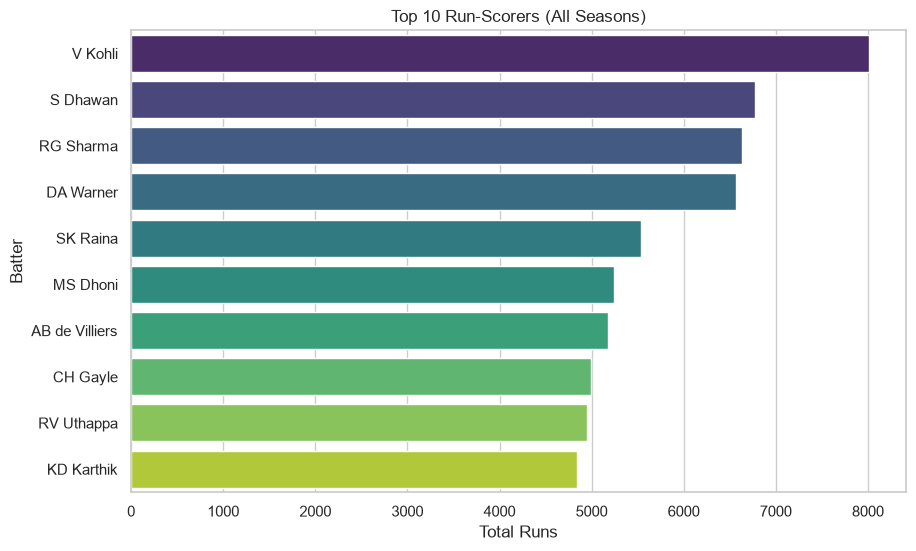

In [13]:
top_scorers = deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, hue=top_scorers.index, palette="viridis", legend=False)
plt.title("Top 10 Run-Scorers (All Seasons)")
plt.xlabel("Total Runs")
plt.ylabel("Batter")
plt.savefig("images/top10_run_scorers.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2: Top 10 Wicket-Takers (All-Time)
Excludes run-outs and other dismissals not credited to the bowler, per cricket scoring rules.

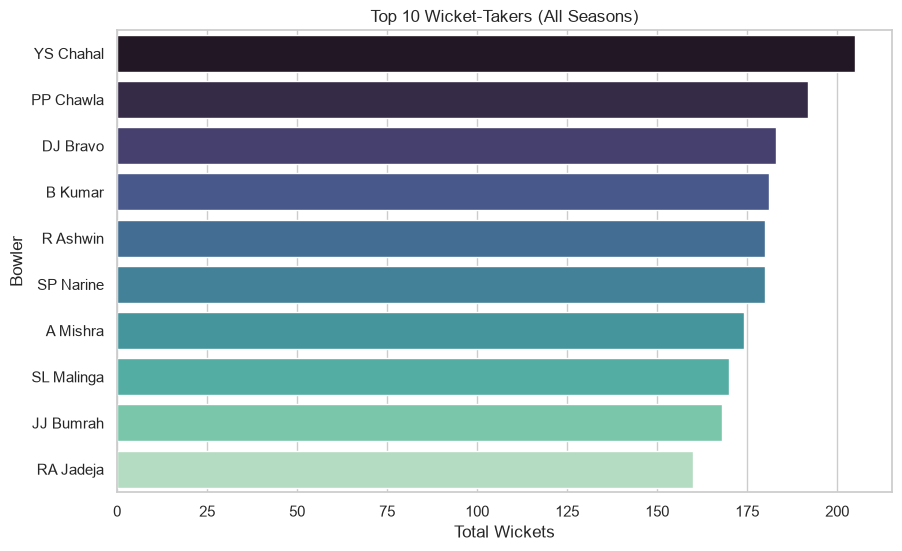

In [14]:
bowler_dismissals = ["caught", "bowled", "lbw", "stumped", "caught and bowled", "hit wicket"]
wickets_only = deliveries[deliveries["dismissal_kind"].isin(bowler_dismissals)]

top_wicket_takers = wickets_only.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_wicket_takers.values, y=top_wicket_takers.index, hue=top_wicket_takers.index, palette="mako", legend=False)
plt.title("Top 10 Wicket-Takers (All Seasons)")
plt.xlabel("Total Wickets")
plt.ylabel("Bowler")
plt.savefig("images/top10_wicket_takers.png", dpi=150, bbox_inches="tight")
plt.show()

### Cleaning Step: Standardize Team Names
Some teams have inconsistent naming across seasons (e.g. "Rising Pune Supergiant" vs "Rising Pune Supergiants", 
"Royal Challengers Bangalore" vs "Royal Challengers Bengaluru"). Standardized these before calculating win 
percentages so each team's stats aren't split across two labels.

In [15]:
name_fixes = {
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
}

matches_clean["team1"] = matches_clean["team1"].replace(name_fixes)
matches_clean["team2"] = matches_clean["team2"].replace(name_fixes)
matches_clean["winner"] = matches_clean["winner"].replace(name_fixes)

### Chart 3: Runs per Match Over Time

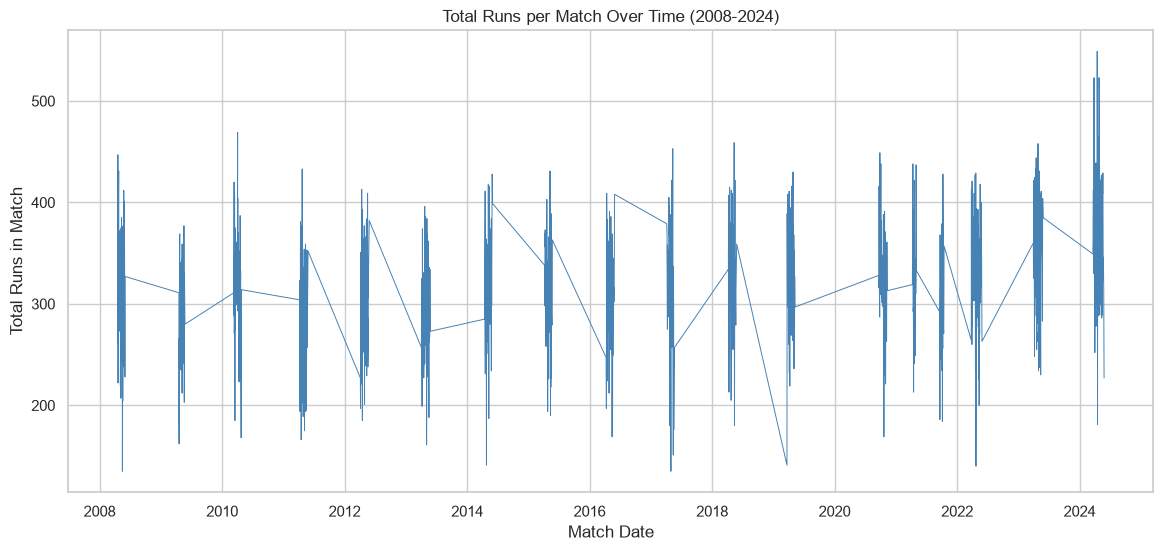

In [16]:
runs_per_match = deliveries.groupby("match_id")["total_runs"].sum().reset_index()
runs_per_match = runs_per_match.merge(matches_clean[["id", "date", "season_sort"]], 
                                        left_on="match_id", right_on="id")
runs_per_match["date"] = pd.to_datetime(runs_per_match["date"])
runs_per_match = runs_per_match.sort_values("date")

plt.figure(figsize=(14, 6))
plt.plot(runs_per_match["date"], runs_per_match["total_runs"], linewidth=0.7, color="steelblue")
plt.title("Total Runs per Match Over Time (2008-2024)")
plt.xlabel("Match Date")
plt.ylabel("Total Runs in Match")
plt.savefig("images/runs_per_match.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 4: Team Win Percentages

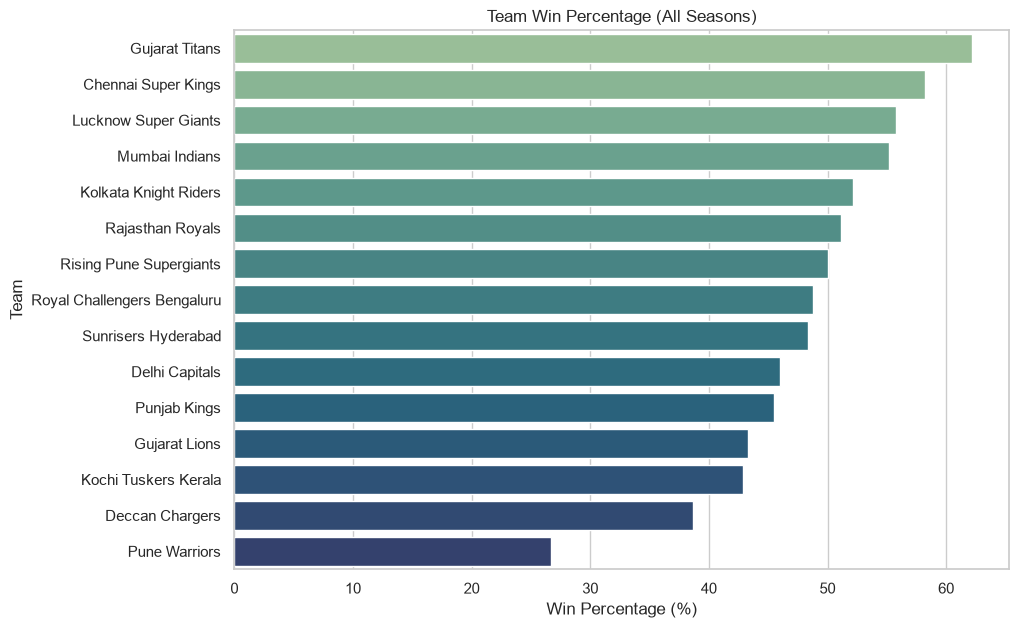

In [17]:
team_matches = pd.concat([matches_clean["team1"], matches_clean["team2"]]).value_counts()
team_wins = matches_clean["winner"].value_counts()

win_pct = (team_wins / team_matches * 100).dropna().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=win_pct.values, y=win_pct.index, hue=win_pct.index, palette="crest", legend=False)
plt.title("Team Win Percentage (All Seasons)")
plt.xlabel("Win Percentage (%)")
plt.ylabel("Team")
plt.savefig("images/team_win_percentage.png", dpi=150, bbox_inches="tight")
plt.show()

### Cleaning Step: Standardize Team Names
Some teams have inconsistent naming across seasons (e.g. "Rising Pune Supergiant" vs "Rising Pune Supergiants", 
"Royal Challengers Bangalore" vs "Royal Challengers Bengaluru"). Standardized these before calculating win 
percentages so each team's stats aren't split across two labels.

In [18]:
name_fixes = {
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
}

matches_clean["team1"] = matches_clean["team1"].replace(name_fixes)
matches_clean["team2"] = matches_clean["team2"].replace(name_fixes)
matches_clean["winner"] = matches_clean["winner"].replace(name_fixes)

## Interactive Filters: Explore by Season

In [19]:
import ipywidgets as widgets

season_list = sorted(matches_clean["season_sort"].unique())

@widgets.interact(season=season_list)
def show_season_stats(season=season_list[-1]):
    season_matches = matches_clean[matches_clean["season_sort"] == season]
    season_match_ids = season_matches["id"].tolist()
    season_deliveries = deliveries[deliveries["match_id"].isin(season_match_ids)]

    top5_runs = season_deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(5)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top5_runs.values, y=top5_runs.index, hue=top5_runs.index, palette="viridis", legend=False)
    plt.title(f"Top 5 Run-Scorers — Season {season}")
    plt.xlabel("Runs")
    plt.tight_layout()
    plt.show()

    season_wins = season_matches["winner"].value_counts()
    plt.figure(figsize=(8, 4))
    sns.barplot(x=season_wins.values, y=season_wins.index, hue=season_wins.index, palette="crest", legend=False)
    plt.title(f"Match Wins by Team — Season {season}")
    plt.xlabel("Wins")
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='season', index=15, options=(np.int64(2007), np.int64(2009), np.int…

## Key Findings

In [20]:
print("All-time top run-scorer:", top_scorers.index[0], "-", top_scorers.iloc[0], "runs")
print("All-time top wicket-taker:", top_wicket_takers.index[0], "-", top_wicket_takers.iloc[0], "wickets")
print("\nTop 5 teams by win %:\n", win_pct.head())
print("\nAverage runs per match:", round(runs_per_match["total_runs"].mean(), 1))
print("Highest-scoring match total:", runs_per_match["total_runs"].max())
print("Lowest-scoring match total:", runs_per_match["total_runs"].min())

All-time top run-scorer: V Kohli - 8014 runs
All-time top wicket-taker: YS Chahal - 205 wickets

Top 5 teams by win %:
 Gujarat Titans           62.222222
Chennai Super Kings      58.227848
Lucknow Super Giants     55.813953
Mumbai Indians           55.172414
Kolkata Knight Riders    52.191235
Name: count, dtype: float64

Average runs per match: 318.4
Highest-scoring match total: 549
Lowest-scoring match total: 135


## Insights

1. **V Kohli leads all-time run-scoring** with 8,014 runs across all seasons, reflecting his consistency 
and longevity as one of the IPL's most dominant batters since its inception.

2. **YS Chahal is the all-time leading wicket-taker** with 205 wickets, highlighting the long-term value 
of a specialist spinner who has featured across many seasons and franchises.

3. **Gujarat Titans have the highest win percentage** at 62.2%, a striking result given they only 
joined the IPL in 2022 — showing exceptionally strong squad building and consistency in their short 
history compared to older, more established franchises.

4. **Match totals vary widely but average around 318 runs.** The highest-scoring match reached 549 runs, 
while the lowest totaled just 135 — showing that while T20 cricket can produce explosive scores, most 
matches settle into a fairly predictable scoring range.

## Conclusion

This analysis of 17 seasons of IPL data (2008-2024) shows that individual excellence (V Kohli in batting, 
YS Chahal in bowling) and strong franchise management (Gujarat Titans' win rate) both play major roles 
in IPL success. Match-level scoring has stayed relatively consistent across seasons, averaging around 
318 runs per match. A natural next step would be studying how toss decisions or powerplay performance 
specifically influence match outcomes.